# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [33]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [34]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [35]:
# Getting the current time just once and then save that value
now = Time.now()

#Showing that saved instant in UTC.
print("UTC:", now.utc.isot)
# .isot gives ISO-8601 format: YYYY-MM-DDTHH:MM:SS.mmm
#Showing the same saved instant in IST (IIT Kanpur's local civil time).
print("IST:", format_iitk(now))

UTC: 2026-09-06T17:18:51.729
IST: 2026-09-06 22:48:51 IST


Explanation: I call `Time.now()` just once and store the result. This way, when I display it in UTC and then in IST, both times come from the exact same moment. UTC is our internal astronomical time scale, and IST is simply UTC + 5h30m, which is the local civil time at IIT Kanpur. Two separate calls to `Time.now()` could differ by fractions of a second, so capturing it once is safer.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [37]:
# I'm creating physical quantities and converting them to the units I need.

# ------------------------------------------------------------
# 1. GTC height: metres -> kilometres
# ------------------------------------------------------------

# Attaching the unit metre to the gtc value 2396.
gtc_height = 2396 * u.m

# Converting the same value from metres to kilometres.
gtc_height_km = gtc_height.to(u.km)


# ------------------------------------------------------------
# 2. Wavelength: nanometres -> frequency in THz
# ------------------------------------------------------------

# Creating the wavelength quantity.
wavelength = 600 * u.nm

# Converting wavelength to frequency using the spectral equivalency.
# Using the relation c = lambda * nu.
frequency_from_wavelength = wavelength.to(
    u.THz,
    equivalencies=u.spectral()
)


# ------------------------------------------------------------
# 3. Coordinate uncertainty: milliarcseconds -> arcseconds
# ------------------------------------------------------------

# Now create the angular uncertainty.
coordinate_uncertainty = 5 * u.mas

# Convert milliarcseconds to arcseconds.
coordinate_uncertainty_arcsec = coordinate_uncertainty.to(u.arcsec)


# ------------------------------------------------------------
# 4. Cadence: minutes -> hours
# ------------------------------------------------------------

# My observing cadence is 10 minutes
cadence = 10 * u.min

# I want that in hours instead.
cadence_hours = cadence.to(u.hour)


# ------------------------------------------------------------
# 5. Radio frequency: GHz -> wavelength in cm
# ------------------------------------------------------------

# The radio frequency I'm working with is 1.4 GHz.
radio_frequency = 1.4 * u.GHz

# Converting to wavelength using the same spectral relation, c = lambda * nu.
radio_wavelength = radio_frequency.to(
    u.cm,
    equivalencies=u.spectral()
)


# ------------------------------------------------------------
#  Finally, I print each original quantity alongside its converted value.
# ------------------------------------------------------------

print("GTC height:              ", gtc_height,
      "->", gtc_height_km)

print("Wavelength:              ", wavelength,
      "->", frequency_from_wavelength)

print("Coordinate uncertainty:  ", coordinate_uncertainty,
      "->", coordinate_uncertainty_arcsec)

print("Cadence:                 ", cadence,
      "->", cadence_hours)

print("Radio frequency:         ", radio_frequency,
      "->", radio_wavelength)

GTC height:               2396.0 m -> 2.396 km
Wavelength:               600.0 nm -> 499.6540966666666 THz
Coordinate uncertainty:   5.0 mas -> 0.005 arcsec
Cadence:                  10.0 min -> 0.16666666666666666 h
Radio frequency:          1.4 GHz -> 21.413747 cm


Explanation: Astropy `Quantity` objects keep numbers tied to their units, which prevents mistakes during conversions. The `.to()` method handles compatible units like m→km, mas→arcsec, and min→h. For wavelength and frequency, the `u.spectral()` equivalency implements \(c=\lambda\nu\), giving ~500 THz for 600 nm and ~21.4 cm for 1.4 GHz.

## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [38]:
# ------------------------------------------------------------
# Astronomical time representations and time arithmetic
# ------------------------------------------------------------

# First I create an Astropy Time object for the beginning of the
# observing interval. START_UTC is can be interpreted as UTC.
planning_start = Time(START_UTC, scale="utc")

# Print the same instant in UTC, Julian Date, Modified Julian Date,
# and IIT Kanpur civil time (IST).
print("UTC :", planning_start.utc.isot)
print("JD  :", planning_start.jd)
print("MJD :", planning_start.mjd)
print("IST :", format_iitk(planning_start))


# ------------------------------------------------------------
# Add 2.25 hours to the starting instant.
# ------------------------------------------------------------

# Astropy allows us to add a physical time quantity directly
# to a Time object.
later = planning_start + 2.25 * u.hour

print("\nAfter adding 2.25 hours:")
print("UTC :", later.utc.isot)
print("IST :", format_iitk(later))


# ------------------------------------------------------------
# Convert an IST-aware Python datetime back to Astropy Time.
# ------------------------------------------------------------

# First convert the original Astropy instant into a Python
# datetime using the IIT Kanpur timezone.
ist_datetime = planning_start.to_datetime(
    timezone=IITK_TIMEZONE
)

# Convert that timezone-aware Python datetime back into Astropy Time.
round_trip = Time(ist_datetime)

# Compare the original and round-tripped instants.
# The difference is calculated in seconds and then converted to
# microseconds for the required < 1 microsecond check.
difference_us = abs(
    (round_trip - planning_start).to_value(u.s)
) * 1e6

print("\nIST-aware Python datetime:", ist_datetime)
print("Round-trip UTC:", round_trip.utc.isot)
print("Difference:", difference_us, "microseconds")

# Verify that the round-trip conversion preserved the instant
# to better than one microsecond.
print("Round-trip < 1 microsecond:",
      difference_us < 1.0)

UTC : 2026-08-30T12:00:00.000
JD  : 2461283.0
MJD : 61282.5
IST : 2026-08-30 17:30:00 IST

After adding 2.25 hours:
UTC : 2026-08-30T14:15:00.000
IST : 2026-08-30 19:45:00 IST

IST-aware Python datetime: 2026-08-30 17:30:00+05:30
Round-trip UTC: 2026-08-30T12:00:00.000
Difference: 0.0 microseconds
Round-trip < 1 microsecond: True


Explanation: The start time is stored as an Astropy `Time` object in UTC. The same instant can be displayed in multiple formats: UTC, JD, MJD, and IST. JD is a continuous day count; MJD = JD - 2400000.5 makes the numbers smaller. Astropy lets us add time quantities directly (e.g., `+ 2.25 * u.hour`). The round-trip conversion from IST-aware Python datetime back to `Time` verifies that the conversion preserves the instant to better than 1 µs.


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [39]:
# ------------------------------------------------------------
# First, I'll Parse the fixed FRB coordinates and construct an ICRS
# SkyCoord object.
# ------------------------------------------------------------

# Parse the Right Ascension string as an angle.
# RA is written in hours, minutes and seconds.
frb_ra = Angle(FRB_RA_J2000)

# Parse the Declination string as an angle.
# Dec is written in degrees, arcminutes and arcseconds.
frb_dec = Angle(FRB_DEC_J2000)

# Construct a scalar celestial coordinate in the ICRS frame.
# SkyCoord combines the RA and Dec into one object representing
# the position of FRB 20220912A on the celestial sphere.
frb_icrs = SkyCoord(
    ra=frb_ra,
    dec=frb_dec,
    frame="icrs"
)

# Print the coordinates in decimal degrees.
print("RA  (decimal degrees):", frb_icrs.ra.deg)
print("Dec (decimal degrees):", frb_icrs.dec.deg)

# Print the coordinates again in sexagesimal notation.
# pad=True keeps the fields consistently formatted.
print("RA  (sexagesimal):", frb_icrs.ra.to_string(unit=u.hourangle, sep=":", pad=True))
print("Dec (sexagesimal):", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True))

# Verify that the decimal-degree values agree with the expected
# values to within 1e-8 degree.
ra_expected = 347.2704120833
dec_expected = 48.7066410556

ra_ok = np.isclose(frb_icrs.ra.deg, ra_expected, atol=1e-8)
dec_ok = np.isclose(frb_icrs.dec.deg, dec_expected, atol=1e-8)

print("RA verification:", ra_ok)
print("Dec verification:", dec_ok)

RA  (decimal degrees): 347.27041208333327
Dec (decimal degrees): 48.70664105555556
RA  (sexagesimal): 23:09:04.8989
Dec (sexagesimal): 48:42:23.9078
RA verification: True
Dec verification: True


Explanation: RA is expressed in hours, minutes, and seconds because 24 hours of RA span the full celestial circle (1h = 15°). Dec is in degrees, like latitude on Earth. The RA and Dec strings are parsed with `Angle`, and a `SkyCoord` in ICRS is constructed. The resulting coordinates match the expected values to within \(10^{-8}\)°.


## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [40]:
# ------------------------------------------------------------
# Q5: Transform the FRB from ICRS to Galactic coordinates
# and then transform it back to ICRS.
# ------------------------------------------------------------

# Transform the FRB position from the ICRS reference frame
# into the Galactic coordinate system.
frb_galactic = frb_icrs.galactic

# Print the Galactic longitude and latitude in degrees.
print("Galactic longitude l:", frb_galactic.l.deg)
print("Galactic latitude  b:", frb_galactic.b.deg)


# ------------------------------------------------------------
# Transform the Galactic coordinate back into ICRS.
# ------------------------------------------------------------

frb_icrs_roundtrip = frb_galactic.icrs


# ------------------------------------------------------------
# Calculate the angular separation between the original
# ICRS coordinate and the round-tripped ICRS coordinate.
# ------------------------------------------------------------

roundtrip_separation = frb_icrs.separation(frb_icrs_roundtrip)

# Convert the separation to microarcseconds.
roundtrip_separation_uas = roundtrip_separation.to(u.microarcsecond)


# Print the round-trip separation.
print("Round-trip separation:", roundtrip_separation_uas)

Galactic longitude l: 106.06496077332801
Galactic latitude  b: -10.784176285402493
Round-trip separation: 0.000310733 uarcsec


***Explanation: ***I transformed the FRB position from the ICRS reference frame to Galactic coordinates, obtaining \(l=106.065^\circ\) and \(b=-10.784^\circ\). I then transformed it back to ICRS and calculated the angular separation from the original coordinate. The separation was only \(0.000310733\) microarcseconds, which is effectively zero. The tiny residual comes from numerical precision in the coordinate transformations and does not represent any physical movement of the FRB.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [41]:
# ------------------------------------------------------------
#Transform the FRB from ICRS to Barycentric True Ecliptic
# coordinates at J2000.
# ------------------------------------------------------------

# Import the ecliptic coordinate frame used in this question.
from astropy.coordinates import BarycentricTrueEcliptic


# ------------------------------------------------------------
# Create the Barycentric True Ecliptic frame at J2000.
# ------------------------------------------------------------

# The equinox specifies the reference epoch used to orient
# the coordinate system.
ecliptic_j2000 = BarycentricTrueEcliptic(
    equinox=Time("J2000")
)


# ------------------------------------------------------------
# Transform the FRB from ICRS into the ecliptic frame.
# ------------------------------------------------------------

frb_ecliptic = frb_icrs.transform_to(ecliptic_j2000)


# ------------------------------------------------------------
# Print ecliptic longitude and latitude.
# ------------------------------------------------------------

print("Ecliptic longitude lambda:",
      frb_ecliptic.lon.deg)

print("Ecliptic latitude beta:",
      frb_ecliptic.lat.deg)


# ------------------------------------------------------------
# Verify that the coordinates lie within their expected ranges.
# ------------------------------------------------------------

lambda_ok = (
    0.0 <= frb_ecliptic.lon.deg < 360.0
)

beta_ok = (
    -90.0 <= frb_ecliptic.lat.deg <= 90.0
)

print("Lambda in valid range:", lambda_ok)
print("Beta in valid range:", beta_ok)


# ------------------------------------------------------------
# Transform the ecliptic coordinate back into ICRS.
# ------------------------------------------------------------

frb_icrs_roundtrip_q6 = frb_ecliptic.transform_to("icrs")


# ------------------------------------------------------------
# Calculate the angular separation between the original
# ICRS coordinate and the round-tripped coordinate.
# ------------------------------------------------------------

roundtrip_separation_q6 = frb_icrs.separation(
    frb_icrs_roundtrip_q6
)

print(
    "Round-trip separation:",
    roundtrip_separation_q6.to(u.microarcsecond)
)

Ecliptic longitude lambda: 14.411187650340095
Ecliptic latitude beta: 48.34695843744783
Lambda in valid range: True
Beta in valid range: True
Round-trip separation: 0 uarcsec


The FRB position is transformed from ICRS to Barycentric True Ecliptic coordinates (J2000), which are defined relative to Earth's orbital plane. The coordinates are \(\lambda\) (ecliptic longitude) and \(\beta\) (ecliptic latitude). Transforming back to ICRS and computing the separation confirms the round-trip preserves the position to numerical precision.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [42]:
# ------------------------------------------------------------
# Angular separation between the fixed FRB position
# and the earlier reported position.
# ------------------------------------------------------------

earlier_position = SkyCoord(
    ra=EARLIER_POSITION_RA,
    dec=EARLIER_POSITION_DEC,
    frame="icrs"
)

# ============================================================
# Part 1: Required great-circle cosine formula
# ============================================================

# Convert RA and Dec to radians because NumPy's
# trigonometric functions use radians.
alpha1 = frb_icrs.ra.to_value(u.rad)
delta1 = frb_icrs.dec.to_value(u.rad)

alpha2 = earlier_position.ra.to_value(u.rad)
delta2 = earlier_position.dec.to_value(u.rad)

# Required spherical great-circle formula:
#
# cos(theta) =
# sin(delta1) sin(delta2)
# + cos(delta1) cos(delta2) cos(alpha2 - alpha1)

cos_theta = (
    np.sin(delta1) * np.sin(delta2)
    + np.cos(delta1) * np.cos(delta2)
    * np.cos(alpha2 - alpha1)
)

# Protect against tiny floating-point values outside [-1, 1].
cos_theta = np.clip(cos_theta, -1.0, 1.0)

# Calculate the separation.
theta_cosine = np.arccos(cos_theta) * u.rad

print("Cosine-formula separation:",
      theta_cosine.to_value(u.arcsec), "arcsec")
print("Cosine-formula separation:",
      theta_cosine.to_value(u.mas), "mas")


# ============================================================
# Part 2: Numerically stable calculation
# ============================================================

# For very small angular separations, arccos(cos(theta))
# can lose precision because cos(theta) is extremely close to 1.
#
# The haversine form is mathematically equivalent but is
# numerically more stable for small angles.

delta_alpha = alpha2 - alpha1
delta_delta = delta2 - delta1

haversine_argument = (
    np.sin(delta_delta / 2.0)**2
    + np.cos(delta1) * np.cos(delta2)
    * np.sin(delta_alpha / 2.0)**2
)

# Protect against tiny floating-point errors.
haversine_argument = np.clip(haversine_argument, 0.0, 1.0)

theta_stable = (
    2.0 * np.arcsin(np.sqrt(haversine_argument))
) * u.rad

print("Stable manual separation:",
      theta_stable.to_value(u.arcsec), "arcsec")
print("Stable manual separation:",
      theta_stable.to_value(u.mas), "mas")


# ============================================================
# Part 3: Independent Astropy calculation
# ============================================================

astropy_separation = frb_icrs.separation(earlier_position)

print("Astropy separation:",
      astropy_separation.to_value(u.arcsec), "arcsec")


# ============================================================
# Part 4: Required 1e-6 arcsec verification
# ============================================================

difference_arcsec = abs(
    theta_stable.to_value(u.arcsec)
    - astropy_separation.to_value(u.arcsec)
)

print("Difference between stable manual and Astropy:",
      difference_arcsec, "arcsec")

print(
    "Agreement within 1e-6 arcsec:",
    difference_arcsec < 1e-6
)


Cosine-formula separation: 1.4922374490540065 arcsec
Cosine-formula separation: 1492.2374490540062 mas
Stable manual separation: 1.4922397261864306 arcsec
Stable manual separation: 1492.2397261864305 mas
Astropy separation: 1.492239726203449 arcsec
Difference between stable manual and Astropy: 1.70183866998741e-11 arcsec
Agreement within 1e-6 arcsec: True


Explanation: The angular separation between two celestial positions is the
shortest great-circle angle between their directions on the celestial
sphere. Using the given great-circle relation, I converted the right ascension and declination values to radians
because NumPy's trigonometric functions use radians. I also used
`np.clip()` to keep the calculated cosine within the valid range
\([-1,1]\), protecting the inverse cosine from small floating-point
round-off errors. The required cosine formula gives a separation of approximately
1.492237 arcsec, or 1492.237 mas. However, the two positions are separated by only about 1.5 arcsec.
For such a small angle, the value of \(\cos(\Delta\theta)\) is
extremely close to 1. Applying `arccos()` to this value can amplify
floating-point round-off and produce a small numerical error. Therefore, I also calculated the same great-circle separation using the mathematically equivalent haversine form, which is numerically
more stable for small angular separations.
Finally, I compared this stable manual result with the independent
Astropy `SkyCoord.separation()` result. The comparison is made using
the full-precision values in arcseconds and is checked against the
required tolerance of \(10^{-6}\) arcsec.
This shows that the discrepancy in the direct cosine calculation is
a numerical-precision effect rather than an error in the underlying
spherical geometry.

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [43]:
# ------------------------------------------------------------
# Define the location of the Gran Telescopio Canarias
# using Astropy's EarthLocation.
# ------------------------------------------------------------

gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

print("GTC longitude:", gtc_location.lon)
print("GTC latitude:", gtc_location.lat)
print("GTC height:", gtc_location.height)

# Verify the values in convenient units.
print("\nVerification:")
print("Longitude:", gtc_location.lon.to_value(u.deg), "deg")
print("Latitude:", gtc_location.lat.to_value(u.deg), "deg")
print("Height:", gtc_location.height.to_value(u.m), "m")

GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999997463 m

Verification:
Longitude: -17.88900000000001 deg
Latitude: 28.758 deg
Height: 2395.9999999997463 m


Explanation: The location of the Gran Telescopio Canarias (GTC) is defined using
Astropy's `EarthLocation`. An observer's location on Earth is specified
by three quantities: longitude, latitude, and height.
For the GTC, the given values are:

- Longitude = \(-17.889^\circ\)
- Latitude = \(+28.758^\circ\)
- Height = \(2396\,\mathrm{m}\)

The negative longitude means that the observatory is **west of the
Greenwich meridian**, while the positive latitude means that it is
**north of the equator**.

The function `EarthLocation.from_geodetic()` converts these geodetic
longitude, latitude, and height values into an Astropy `EarthLocation`
object. This object can then be used to calculate quantities that
depend on the observer's position on Earth, such as the target's
altitude, azimuth, and hour angle. The GTC location is therefore essential for determining when
FRB 20220912A is observable from the telescope.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [44]:
# ------------------------------------------------------------
#  Calculate GTC Local Sidereal Time and hour angle
# at 2026-08-31T00:00:00Z.
# ------------------------------------------------------------

# Define the required observing time in UTC.
q9_time = Time("2026-08-31T00:00:00", scale="utc")

# Create an Astroplan Observer using the GTC location.
gtc_observer = Observer(location=gtc_location)

# Calculate the apparent Local Sidereal Time at GTC.
q9_lst = gtc_observer.local_sidereal_time(
    q9_time,
    kind="apparent"
)

# Convert the FRB's right ascension to an Angle.
frb_ra = Angle(FRB_RA_J2000)

# Calculate hour angle:
# H = LST - RA
q9_hour_angle = (q9_lst - frb_ra).wrap_at(12 * u.hourangle)

# Determine the target's position relative to the meridian.
if q9_hour_angle < 0 * u.hourangle:
    meridian_status = "east of the meridian"
elif q9_hour_angle > 0 * u.hourangle:
    meridian_status = "west of the meridian"
else:
    meridian_status = "transiting"

# Print the requested results.
print("UTC:", format_utc(q9_time))
print("IIT Kanpur time:", format_iitk(q9_time))
print("Apparent GTC LST:", q9_lst.to_string(unit=u.hour, sep=":"))
print("Hour angle H:", q9_hour_angle.to_string(unit=u.hour, sep=":"))
print("Target is:", meridian_status)

UTC: 2026-08-31 00:00:00 UTC
IIT Kanpur time: 2026-08-31 05:30:00 IST
Apparent GTC LST: 21:25:12.20821623
Hour angle H: -1:43:52.69068377
Target is: east of the meridian


Explanation: At `2026-08-31T00:00:00Z`, the apparent Local Sidereal Time
(LST) at the GTC is \(21^\mathrm{h}25^\mathrm{m}12.208^\mathrm{s}\).
Local Sidereal Time represents the right ascension that is currently
on the local meridian. The FRB has a right ascension of
\(23^\mathrm{h}09^\mathrm{m}04.8989^\mathrm{s}\).
The hour angle is calculated as

\[
H = \mathrm{LST} - \alpha.
\]

For this observation time,

\[
H = -1^\mathrm{h}43^\mathrm{m}52.691^\mathrm{s}.
\]

The hour angle is wrapped to the range \(-12\) to \(+12\) hours so
that the object's position relative to the meridian is unambiguous.

With the convention used here:

- \(H < 0\): target is east of the meridian.
- \(H = 0\): target is transiting the meridian.
- \(H > 0\): target is west of the meridian.

Since the calculated hour angle is negative, FRB 20220912A is
**east of the meridian** at this instant. It has therefore not yet
reached meridian transit.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [45]:
# ------------------------------------------------------------
# Find the nearest sampled meridian transit.
# ------------------------------------------------------------

# Calculate apparent Local Sidereal Time for all 145 samples.
lst_all = gtc_observer.local_sidereal_time(
    times,
    kind="apparent"
)

# Calculate the FRB hour angle at every sample.
# H = LST - RA
hour_angle_all = (lst_all - frb_ra).wrap_at(12 * u.hourangle)

# Find the sample where the absolute hour angle is smallest.
nearest_transit_index = np.argmin(
    np.abs(hour_angle_all.to_value(u.hourangle))
)

# Extract the corresponding values.
nearest_transit_time = times[nearest_transit_index]
nearest_transit_lst = lst_all[nearest_transit_index]
nearest_transit_hour_angle = hour_angle_all[nearest_transit_index]

# Print the requested information.
print("Nearest sampled transit:")
print("Sample index:", nearest_transit_index)
print("UTC:", format_utc(nearest_transit_time))
print("IIT Kanpur time:", format_iitk(nearest_transit_time))
print(
    "Apparent GTC LST:",
    nearest_transit_lst.to_string(unit=u.hour, sep=":")
)
print(
    "Hour angle H:",
    nearest_transit_hour_angle.to_string(unit=u.hour, sep=":")
)

Nearest sampled transit:
Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST
Apparent GTC LST: 23:05:28.63507714
Hour angle H: -0:03:36.26382286


Explanation: The apparent GTC Local Sidereal Time and the target hour angle were
calculated for all 145 samples in the 10-minute observing grid.
Meridian transit occurs when the hour angle is exactly zero.
Therefore, the nearest sampled transit is found by minimizing the
absolute value of the hour angle, \(|H|\), over all 145 samples.

The nearest sampled transit occurs at sample index 82:

- UTC: `2026-08-31 01:40:00 UTC`
- IIT Kanpur time: `2026-08-31 07:10:00 IST`
- Apparent GTC LST: \(23^\mathrm{h}05^\mathrm{m}28.635^\mathrm{s}\)
- Hour angle: \(-0^\mathrm{h}03^\mathrm{m}36.264^\mathrm{s}\)
The hour angle is very close to zero, indicating that the FRB is
very close to the meridian. Since the hour angle is slightly negative,
the target is still just east of the meridian at this sampled instant.
This is a sampled approximation rather than the exact transit instant
because the calculation is performed only at 10-minute intervals.
The true transit can occur between two consecutive grid samples.
Therefore, the sample with the smallest absolute hour angle is the
nearest sampled transit, not necessarily the exact physical transit
time.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [46]:


# Defining the FRB position in the ICRS frame.
frb_icrs = SkyCoord(
    ra=FRB_RA_J2000,
    dec=FRB_DEC_J2000,
    frame="icrs"
)

# Extract the target declination and GTC latitude in degrees.
frb_dec_deg = frb_icrs.dec.to_value(u.deg)
gtc_lat_deg = GTC_LATITUDE_DEG

# ---------------------------------------------------------
# Analytic calculation at upper meridian transit
# ---------------------------------------------------------

# At upper transit:
# h_transit = 90 deg - |latitude - declination|
transit_altitude_deg = 90.0 - abs(gtc_lat_deg - frb_dec_deg)

# Zenith distance is measured from the zenith:
# z = 90 deg - h
transit_zenith_distance_deg = 90.0 - transit_altitude_deg

# ---------------------------------------------------------
# Astropy calculation for all 145 sampled times
# ---------------------------------------------------------

# Create a vacuum AltAz frame.
# pressure = 0 means atmospheric refraction is not included.
altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

# Transform the fixed ICRS position into AltAz at every sample time.
frb_altaz = frb_icrs.transform_to(altaz_frame)

# Find the largest altitude among the 145 sampled times.
sampled_altitudes = frb_altaz.alt
max_sampled_index = np.nanargmax(sampled_altitudes)
max_sampled_altitude = sampled_altitudes[max_sampled_index]

# Calculate the corresponding zenith distance.
max_sampled_zenith_distance = 90 * u.deg - max_sampled_altitude

# Time corresponding to the largest sampled altitude.
max_sampled_time = times[max_sampled_index]

# Difference between analytic transit altitude and
# the largest altitude actually sampled on the 10-minute grid.
altitude_difference = (
    transit_altitude_deg * u.deg - max_sampled_altitude
)

# ---------------------------------------------------------
# Print the results
# ---------------------------------------------------------

print("Analytic upper-transit altitude:")
print(f"{transit_altitude_deg:.6f} deg")

print("\nAnalytic zenith distance:")
print(f"{transit_zenith_distance_deg:.6f} deg")

print("\nLargest sampled Astropy altitude:")
print(max_sampled_altitude.to_string(
    unit=u.deg,
    decimal=True,
    precision=6
))

print("\nZenith distance at largest sampled altitude:")
print(max_sampled_zenith_distance.to_string(
    unit=u.deg,
    decimal=True,
    precision=6
))

print("\nSample index:", max_sampled_index)
print("UTC:", format_utc(max_sampled_time))
print("IIT Kanpur time:", format_iitk(max_sampled_time))

print("\nDifference (analytic - sampled):")
print(altitude_difference.to_value(u.deg), "deg")

Analytic upper-transit altitude:
70.051359 deg

Analytic zenith distance:
19.948641 deg

Largest sampled Astropy altitude:
69.883913

Zenith distance at largest sampled altitude:
20.116087

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST

Difference (analytic - sampled):
0.16744611993713931 deg


Explanation: At upper meridian transit, the altitude depends only on the observer's latitude and the target's declination:

**h_transit = 90° − |latitude − declination|**

Plugging in GTC's latitude (28.758°) and the FRB's declination (48.706641°):

**h_transit = 90° − |28.758° − 48.706641°| = 70.051359°**

The zenith distance is just **z = 90° − h = 19.948641°**.

To check this numerically, I transformed the FRB to a vacuum AltAz frame and found the highest sampled altitude at index 82: **69.883913°**. It's slightly lower than the analytic value because the 10-minute grid doesn't sample exactly at the transit instant.

## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [50]:
# The nearest sampled transit from Q10 is at index 82.
transit_index = nearest_transit_index

# Two hours corresponds to 12 samples because the grid spacing is 10 minutes.
samples_two_hours = int((2 * 60) / STEP_MINUTES)

# Select the three required samples.
selected_indices = [
    transit_index - samples_two_hours,
    transit_index,
    transit_index + samples_two_hours
]

# Convert the GTC latitude and FRB declination to radians
# because NumPy trigonometric functions use radians.
phi = np.deg2rad(GTC_LATITUDE_DEG)
delta = frb_icrs.dec.to_value(u.rad)

print("Q12: Altitude around meridian transit\n")

for index in selected_indices:

    # Hour angle of this sample in radians.
    H = hour_angle_all[index].to_value(u.rad)

    # Calculate altitude using the spherical astronomy equation:
    #
    # sin(h) = sin(phi) sin(delta)
    #          + cos(phi) cos(delta) cos(H)
    sin_h = (
        np.sin(phi) * np.sin(delta)
        + np.cos(phi) * np.cos(delta) * np.cos(H)
    )

    # Numerical rounding can very slightly push sin_h outside [-1, 1],
    # so clip it before applying arcsin.
    sin_h = np.clip(sin_h, -1.0, 1.0)

    calculated_altitude = np.rad2deg(np.arcsin(sin_h))

    # Astropy altitude at the same sample.
    astropy_altitude = frb_altaz.alt[index].to_value(u.deg)

    # Difference between the manual calculation and Astropy.
    difference = calculated_altitude - astropy_altitude

    print(f"Sample index: {index}")
    print("UTC:", format_utc(times[index]))
    print("IIT Kanpur time:", format_iitk(times[index]))
    print(
        "Hour angle H:",
        hour_angle_all[index].to_string(
            unit=u.hourangle,
            sep=":",
            precision=3
        )
    )
    print(f"Calculated altitude: {calculated_altitude:.6f} deg")
    print(f"Astropy altitude:    {astropy_altitude:.6f} deg")
    print(f"Difference:          {difference:.9f} deg")
    print()

Q12: Altitude around meridian transit

Sample index: 70
UTC: 2026-08-30 23:40:00 UTC
IIT Kanpur time: 2026-08-31 05:10:00 IST
Hour angle H: -2:03:55.976
Calculated altitude: 59.031949 deg
Astropy altitude:    58.781576 deg
Difference:          0.250372932 deg

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST
Hour angle H: -0:03:36.264
Calculated altitude: 70.039347 deg
Astropy altitude:    69.883913 deg
Difference:          0.155434644 deg

Sample index: 94
UTC: 2026-08-31 03:40:00 UTC
IIT Kanpur time: 2026-08-31 09:10:00 IST
Hour angle H: 1:56:43.448
Calculated altitude: 60.063044 deg
Astropy altitude:    60.162610 deg
Difference:          -0.099566051 deg



Explanation:

I picked three samples: two hours before transit (index 70), at the nearest transit (index 82), and two hours after (index 94). Using the standard altitude equation:

**sin(h) = sin(φ)sin(δ) + cos(φ)cos(δ)cos(H)**

I calculated the altitude at each point. The pattern is clear: the target rises to its highest point near transit and then sinks back down.

| Sample | Hour Angle | Calculated Altitude | Astropy Altitude |
|--------|------------|---------------------|------------------|
| 70 (2h before) | -2h03m56s | 59.031949° | 58.781576° |
| 82 (transit) | -0h03m36s | 70.039347° | 69.883913° |
| 94 (2h after) | +1h56m43s | 60.063044° | 60.162610° |

The target is highest at transit and lower on either side. The manual calculation matches Astropy's AltAz values closely—the small differences come from the fact that Astropy accounts for time-dependent coordinate transformations, while I used a simpler spherical formula.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [51]:
# Minimum altitude requirement.
h_min_deg = MIN_TARGET_ALTITUDE_DEG

# Convert the relevant angles to radians for NumPy trigonometric functions.
phi = np.deg2rad(GTC_LATITUDE_DEG)
delta = frb_icrs.dec.to_value(u.rad)
h_min = np.deg2rad(h_min_deg)

# ---------------------------------------------------------
# Analytical limiting hour angle
# ---------------------------------------------------------

# From
# sin(h_min) = sin(phi)sin(delta)
#              + cos(phi)cos(delta)cos(H0)
#
# rearrange to obtain cos(H0).
cos_H0 = (
    np.sin(h_min) - np.sin(phi) * np.sin(delta)
) / (
    np.cos(phi) * np.cos(delta)
)

# Protect against tiny floating-point errors that could
# make cos_H0 slightly larger than 1 or smaller than -1.
cos_H0 = np.clip(cos_H0, -1.0, 1.0)

# Limiting hour angle in radians.
H0_rad = np.arccos(cos_H0)

# Convert to degrees.
H0_deg = np.rad2deg(H0_rad)

# Convert degrees to sidereal hours.
# 15 degrees = 1 sidereal hour.
H0_hours = H0_deg / 15.0

# Total hour-angle range from -H0 to +H0.
total_hour_angle_hours = 2.0 * H0_hours

# ---------------------------------------------------------
# Compare with the sampled 10-minute grid
# ---------------------------------------------------------

# Boolean mask: True wherever target altitude is at least 20 deg.
above_altitude_limit = frb_altaz.alt >= h_min_deg * u.deg

# Count the samples satisfying the altitude requirement.
number_of_samples_above_limit = np.count_nonzero(
    above_altitude_limit
)

# Total duration represented by the selected samples.
sampled_duration_hours = (
    number_of_samples_above_limit * STEP_MINUTES / 60.0
)

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("Minimum altitude:", h_min_deg, "deg")

print("\nAnalytical limiting hour angle H0:")
print(f"{H0_deg:.6f} deg")
print(f"{H0_hours:.6f} sidereal hours")

print("\nTotal hour-angle range 2H0:")
print(f"{total_hour_angle_hours:.6f} sidereal hours")

print("\nSampled grid:")
print("Number of samples with altitude >= 20 deg:",
      number_of_samples_above_limit)

print("10-minute sample spacing:", STEP_MINUTES, "minutes")

print("Sampled duration represented by these samples:",
      f"{sampled_duration_hours:.6f} hours")

Minimum altitude: 20.0 deg

Analytical limiting hour angle H0:
91.927477 deg
6.128498 sidereal hours

Total hour-angle range 2H0:
12.256997 sidereal hours

Sampled grid:
Number of samples with altitude >= 20 deg: 74
10-minute sample spacing: 10 minutes
Sampled duration represented by these samples: 12.333333 hours


Explanation: The source stays above 20° when the hour angle is within ±6.13 hours of transit, giving a total of ~12.26 hours. The 10-minute grid shows 74 samples above 20°, which works out to 12.33 hours—close enough. The slight difference is just because the grid doesn't sample the exact transition points.

# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [52]:
# Create the GTC vacuum AltAz frame for all 145 observing times.
# Pressure = 0 means that atmospheric refraction is not included.
gtc_altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

# Transform the FRB from ICRS coordinates into the local GTC AltAz frame.
frb_gtc_altaz = frb_icrs.transform_to(gtc_altaz_frame)

# Astropy's .secz gives the approximate airmass X = sec(z),
# where z is the zenith distance.
target_airmass = np.asarray(
    frb_gtc_altaz.secz,
    dtype=float
).copy()

# Airmass values are physically meaningful only when the target
# is above the horizon, finite, and at least 1.
invalid = (
    (frb_gtc_altaz.alt <= 0 * u.deg)
    | ~np.isfinite(target_airmass)
    | (target_airmass < 1.0)
)

# Replace physically invalid values with NaN.
target_airmass[invalid] = np.nan

# Keep only finite values when calculating the range.
finite_airmass = target_airmass[np.isfinite(target_airmass)]

minimum_airmass = np.min(finite_airmass)
maximum_airmass = np.max(finite_airmass)

# Locate the sample having the smallest airmass.
best_airmass_index = np.nanargmin(target_airmass)
best_airmass_time = times[best_airmass_index]

# Apply the assignment's allowed range:
# 1 <= X <= 2.5
airmass_ok = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1.0)
    & (target_airmass <= MAX_AIRMASS)
)

number_of_airmass_ok_samples = np.count_nonzero(airmass_ok)

# Print the requested results.
print("Finite target airmass range:")
print(f"Minimum X: {minimum_airmass:.6f}")
print(f"Maximum X: {maximum_airmass:.6f}")

print("\nBest airmass:")
print(f"X = {minimum_airmass:.6f}")
print("Sample index:", best_airmass_index)
print("UTC:", format_utc(best_airmass_time))
print("IIT Kanpur time:", format_iitk(best_airmass_time))

print("\nSamples satisfying 1 <= X <= 2.5:")
print(number_of_airmass_ok_samples)

Finite target airmass range:
Minimum X: 1.064965
Maximum X: 55.338451

Best airmass:
X = 1.064965
Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST

Samples satisfying 1 <= X <= 2.5:
68


I converted the target's secz values to an airmass array and replaced anything below the horizon, non-finite, or less than 1 with NaN. The finite range is 1.065 ≤ X ≤ 55.338, with the best (lowest) airmass at transit: X = 1.064965. Only 68 samples satisfy the observing limit of X ≤ 2.5. Below-horizon values are meaningless because the target isn't visible.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [55]:
# Calculate Sun and Moon observing conditions.

# ---------------------------------------------------------
# Sun position
# ---------------------------------------------------------

# Calculate the Sun's position at all 145 observing times.
sun_icrs = get_sun(times)

# Transform the Sun into the local GTC horizon system.
sun_altaz = sun_icrs.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

# Sun altitude at every sample.
sun_altitude = sun_altaz.alt


# ---------------------------------------------------------
# Moon position
# ---------------------------------------------------------

# Calculate the Moon's geocentric position at all observing times.
moon_icrs = get_body(
    "moon",
    times,
    location=gtc_location
)

# Transform the Moon into the local GTC horizon system.
moon_altaz = moon_icrs.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

# Moon altitude at every sample.
moon_altitude = moon_altaz.alt


# ---------------------------------------------------------
# Moon airmass
# ---------------------------------------------------------

# Astropy's secz gives the approximate airmass:
# X = sec(z) = 1 / cos(z)
moon_airmass = np.asarray(
    moon_altaz.secz,
    dtype=float
).copy()

# Keep Moon airmass only when:
#   1. Moon is above the horizon
#   2. airmass is finite
#   3. 1 <= X <= 3
invalid_moon_airmass = (
    (moon_altitude <= 0 * u.deg)
    | ~np.isfinite(moon_airmass)
    | (moon_airmass < 1.0)
    | (moon_airmass > 3.0)
)

moon_airmass[invalid_moon_airmass] = np.nan


# ---------------------------------------------------------
# Moon-target angular separation
# ---------------------------------------------------------

# Calculate the angular separation between the Moon and FRB.
moon_target_separation = moon_icrs.separation(frb_icrs)


# ---------------------------------------------------------
# Moon illuminated fraction
# ---------------------------------------------------------

# Geocentric Sun-Moon elongation.
sun_moon_elongation = sun_icrs.separation(moon_icrs)

# Approximate illuminated fraction specified by the assignment:
#
# f = (1 - cos(epsilon)) / 2
#
# Convert the angle to radians because NumPy's cos() expects radians.
epsilon_rad = sun_moon_elongation.to_value(u.rad)

illuminated_fraction = (
    1.0 - np.cos(epsilon_rad)
) / 2.0


# ---------------------------------------------------------
# Moon classification
# ---------------------------------------------------------

# Create an array to store the labels.
moon_label = np.full(
    len(times),
    "Gray",
    dtype=object
)

# Determine which samples have finite diagnostic inputs.
finite_inputs = (
    np.isfinite(moon_altitude.to_value(u.deg))
    & np.isfinite(moon_target_separation.to_value(u.deg))
    & np.isfinite(illuminated_fraction)
)

# Unknown rule.
unknown = ~finite_inputs
moon_label[unknown] = "Unknown"

# Bright rule.
bright = (
    finite_inputs
    & (
        (
            (illuminated_fraction >= 0.70)
            & (moon_altitude.to_value(u.deg) > 10.0)
        )
        |
        (moon_target_separation.to_value(u.deg) <= 45.0)
    )
)

moon_label[bright] = "Bright"

# Dark rule.
dark = (
    finite_inputs
    & (
        (moon_altitude.to_value(u.deg) < 0.0)
        |
        (
            (moon_target_separation.to_value(u.deg) >= 90.0)
            & (illuminated_fraction <= 0.25)
        )
    )
)

# Dark is applied after Bright, exactly as specified.
moon_label[dark] = "Dark"


# ---------------------------------------------------------
# Print diagnostic values
# ---------------------------------------------------------

print("Moon/Sun diagnostics at all samples:\n")

for index in range(len(times)):
    print(f"Sample {index}:")
    print("UTC:", format_utc(times[index]))
    print("IIT Kanpur time:", format_iitk(times[index]))
    print(
        f"Sun altitude: "
        f"{sun_altitude[index].to_value(u.deg):.3f} deg"
    )
    print(
        f"Moon altitude: "
        f"{moon_altitude[index].to_value(u.deg):.3f} deg"
    )
    print(
        f"Moon airmass: "
        f"{moon_airmass[index]:.3f}"
    )
    print(
        f"Moon-target separation: "
        f"{moon_target_separation[index].to_value(u.deg):.3f} deg"
    )
    print(
        f"Illuminated fraction: "
        f"{illuminated_fraction[index]:.3f}"
    )
    print("Moon label:", moon_label[index])
    print()

# ---------------------------------------------------------
# Print Moon label at the nearest sampled transit
# ---------------------------------------------------------

print("Moon condition at nearest sampled transit:")
print("Sample index:", nearest_transit_index)
print("UTC:", format_utc(times[nearest_transit_index]))
print(
    "IIT Kanpur time:",
    format_iitk(times[nearest_transit_index])
)
print("Moon label:", moon_label[nearest_transit_index])

Moon/Sun diagnostics at all samples:

Sample 0:
UTC: 2026-08-30 12:00:00 UTC
IIT Kanpur time: 2026-08-30 17:30:00 IST
Sun altitude: 63.876 deg
Moon altitude: -37.679 deg
Moon airmass: nan
Moon-target separation: 46.382 deg
Illuminated fraction: 0.941
Moon label: Dark

Sample 1:
UTC: 2026-08-30 12:10:00 UTC
IIT Kanpur time: 2026-08-30 17:40:00 IST
Sun altitude: 65.333 deg
Moon altitude: -39.408 deg
Moon airmass: nan
Moon-target separation: 46.369 deg
Illuminated fraction: 0.940
Moon label: Dark

Sample 2:
UTC: 2026-08-30 12:20:00 UTC
IIT Kanpur time: 2026-08-30 17:50:00 IST
Sun altitude: 66.646 deg
Moon altitude: -41.091 deg
Moon airmass: nan
Moon-target separation: 46.356 deg
Illuminated fraction: 0.940
Moon label: Dark

Sample 3:
UTC: 2026-08-30 12:30:00 UTC
IIT Kanpur time: 2026-08-30 18:00:00 IST
Sun altitude: 67.787 deg
Moon altitude: -42.723 deg
Moon airmass: nan
Moon-target separation: 46.343 deg
Illuminated fraction: 0.940
Moon label: Dark

Sample 4:
UTC: 2026-08-30 12:40:00 UTC

Explanation: I used Astropy's ephemeris to get Sun and Moon positions for every sample. The Moon classification follows the course rules: first it gives Bright, then Dark. At the nearest transit (index 82), the Moon label is Bright—meaning conditions aren't ideal for observing.

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [56]:
def visibility(altitude, airmass, sun_altitude, moon_separation):
    """
    Determine whether each time sample satisfies all four
    GTC observing conditions.
    """

    # Convert all inputs to 1-D NumPy arrays.
    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)

    # Validate that all inputs are one-dimensional arrays
    # and have the same number of elements.
    arrays = [altitude, airmass, sun_altitude, moon_separation]

    if not all(array.ndim == 1 for array in arrays):
        raise ValueError("All inputs must be one-dimensional arrays.")

    if not all(array.shape == altitude.shape for array in arrays):
        raise ValueError("All input arrays must have the same length.")

    # Individual observing conditions.
    altitude_ok = (altitude >= MIN_TARGET_ALTITUDE_DEG)

    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1.0)
        & (airmass <= MAX_AIRMASS)
    )

    sun_ok = (sun_altitude <= MAX_SUN_ALTITUDE_DEG)

    moon_ok = (moon_separation >= MIN_MOON_SEPARATION_DEG)

    # All four conditions must be satisfied simultaneously.
    observable = (
        altitude_ok
        & airmass_ok
        & sun_ok
        & moon_ok
    )

    return observable


# Calculate the independent conditions for the 145 samples.
altitude_condition = (
    np.asarray(frb_gtc_altaz.alt.to_value(u.deg), dtype=float)
    >= MIN_TARGET_ALTITUDE_DEG
)

airmass_condition = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1.0)
    & (target_airmass <= MAX_AIRMASS)
)

sun_condition = (
    np.asarray(sun_altaz.alt.to_value(u.deg), dtype=float)
    <= MAX_SUN_ALTITUDE_DEG
)

moon_condition = (
    np.asarray(moon_target_separation.to_value(u.deg), dtype=float)
    >= MIN_MOON_SEPARATION_DEG
)

# Use the required visibility function.
preferred_visibility = visibility(
    frb_gtc_altaz.alt.to_value(u.deg),
    target_airmass,
    sun_altaz.alt.to_value(u.deg),
    moon_target_separation.to_value(u.deg),
)

# Print independent condition counts.
print("Samples satisfying target altitude >= 20 deg:",
      np.count_nonzero(altitude_condition))

print("Samples satisfying target airmass 1 <= X <= 2.5:",
      np.count_nonzero(airmass_condition))

print("Samples satisfying astronomical darkness:",
      np.count_nonzero(sun_condition))

print("Samples satisfying Moon separation >= 30 deg:",
      np.count_nonzero(moon_condition))

print("Samples satisfying all four conditions:",
      np.count_nonzero(preferred_visibility))

print("Overall visibility exists:",
      bool(np.any(preferred_visibility)))

Samples satisfying target altitude >= 20 deg: 74
Samples satisfying target airmass 1 <= X <= 2.5: 68
Samples satisfying astronomical darkness: 51
Samples satisfying Moon separation >= 30 deg: 145
Samples satisfying all four conditions: 51
Overall visibility exists: True


Explanation: The visibility() function checks four conditions element-wise:
Target altitude ≥ 20°
Airmass between 1 and 2.5
Sun altitude ≤ -18° (astronomical night)
Moon separation ≥ 30°

All conditions must be true simultaneously. The combined result gives 51 observable samples, so the overall answer is True.

## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [57]:
# Two times required by Q17:
# (a) nearest sampled transit from Q10
# (b) 2026-08-31 06:00:00 UTC

transit_time = times[transit_index]

q17_times = Time(
    [
        transit_time.jd,
        Time("2026-08-31T06:00:00", scale="utc").jd
    ],
    format="jd",
    scale="utc"
)
# Calculate the target position at these two times.
q17_altaz_frame = AltAz(
    obstime=q17_times,
    location=gtc_location,
    pressure=0 * u.hPa
)

q17_target_altaz = frb_icrs.transform_to(q17_altaz_frame)

# Calculate target airmass.
q17_airmass = np.asarray(
    q17_target_altaz.secz,
    dtype=float
)

# Remove physically invalid airmass values.
q17_airmass[
    (q17_target_altaz.alt <= 0 * u.deg)
    | ~np.isfinite(q17_airmass)
    | (q17_airmass < 1.0)
] = np.nan

# Calculate Sun altitude.
q17_sun_icrs = get_sun(q17_times)

q17_sun_altaz = q17_sun_icrs.transform_to(q17_altaz_frame)

# Calculate Moon position and Moon-target separation.
q17_moon_icrs = get_body(
    "moon",
    q17_times,
    location=gtc_location
)

q17_moon_target_separation = q17_moon_icrs.separation(
    frb_icrs
)

# Evaluate the four individual conditions.
q17_altitude_ok = (
    q17_target_altaz.alt.to_value(u.deg)
    >= MIN_TARGET_ALTITUDE_DEG
)

q17_airmass_ok = (
    np.isfinite(q17_airmass)
    & (q17_airmass >= 1.0)
    & (q17_airmass <= MAX_AIRMASS)
)

q17_sun_ok = (
    q17_sun_altaz.alt.to_value(u.deg)
    <= MAX_SUN_ALTITUDE_DEG
)

q17_moon_ok = (
    q17_moon_target_separation.to_value(u.deg)
    >= MIN_MOON_SEPARATION_DEG
)

# Use the required visibility function.
q17_visibility = visibility(
    q17_target_altaz.alt.to_value(u.deg),
    q17_airmass,
    q17_sun_altaz.alt.to_value(u.deg),
    q17_moon_target_separation.to_value(u.deg)
)

# Print all required diagnostics.
for i, time_value in enumerate(q17_times):
    print(f"\n--- Case {i + 1} ---")
    print("UTC:", format_utc(time_value))
    print("IIT Kanpur time:", format_iitk(time_value))

    print(
        "Target altitude:",
        f"{q17_target_altaz.alt[i].to_value(u.deg):.6f} deg"
    )

    print(
        "Target airmass:",
        f"{q17_airmass[i]:.6f}"
    )

    print(
        "Sun altitude:",
        f"{q17_sun_altaz.alt[i].to_value(u.deg):.6f} deg"
    )

    print(
        "Moon-target separation:",
        f"{q17_moon_target_separation[i].to_value(u.deg):.6f} deg"
    )

    print("Altitude condition:", bool(q17_altitude_ok[i]))
    print("Airmass condition:", bool(q17_airmass_ok[i]))
    print("Sun condition:", bool(q17_sun_ok[i]))
    print("Moon-separation condition:", bool(q17_moon_ok[i]))
    print("preferred_visibility:", bool(q17_visibility[i]))


--- Case 1 ---
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST
Target altitude: 69.883913 deg
Target airmass: 1.064965
Sun altitude: -51.955922 deg
Moon-target separation: 45.226754 deg
Altitude condition: True
Airmass condition: True
Sun condition: True
Moon-separation condition: True
preferred_visibility: True

--- Case 2 ---
UTC: 2026-08-31 06:00:00 UTC
IIT Kanpur time: 2026-08-31 11:30:00 IST
Target altitude: 37.986487 deg
Target airmass: 1.624760
Sun altitude: -11.282037 deg
Moon-target separation: 44.698146 deg
Altitude condition: True
Airmass condition: True
Sun condition: False
Moon-separation condition: True
preferred_visibility: False


Explanation: At transit (index 82), all four conditions pass—target is visible. But at 06:00 UTC, the Sun altitude is only -11.28°, which fails the astronomical darkness requirement (-18°). So even though the target is still high enough, it's not visible. Transit alone doesn't guarantee observability.




# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Number of observable windows: 1

Window 1
Start sample: 54
End sample: 104
Start UTC: 2026-08-30 21:00:00 UTC
Start IIT Kanpur time: 2026-08-31 02:30:00 IST
End UTC: 2026-08-31 05:20:00 UTC
End IIT Kanpur time: 2026-08-31 10:50:00 IST
Sample-centre duration: 8.3333 hours

===== Window 1 properties =====
Start: 2026-08-30 21:00:00 UTC | 2026-08-31 02:30:00 IST
End: 2026-08-31 05:20:00 UTC | 2026-08-31 10:50:00 IST
Sample-centre duration: 8.3333 hours
Best target airmass: 1.064965
Best-airmass sample index: 82
Best-airmass UTC: 2026-08-31 01:40:00 UTC
Best-airmass IIT Kanpur time: 2026-08-31 07:10:00 IST
Midpoint sample index: 79
Midpoint UTC: 2026-08-31 01:10:00 UTC
Midpoint IIT Kanpur time: 2026-08-31 06:40:00 IST
Midpoint Moon label: Bright
Figure saved to:
assignment_outputs/frb_20220912a_gtc_airmass.png


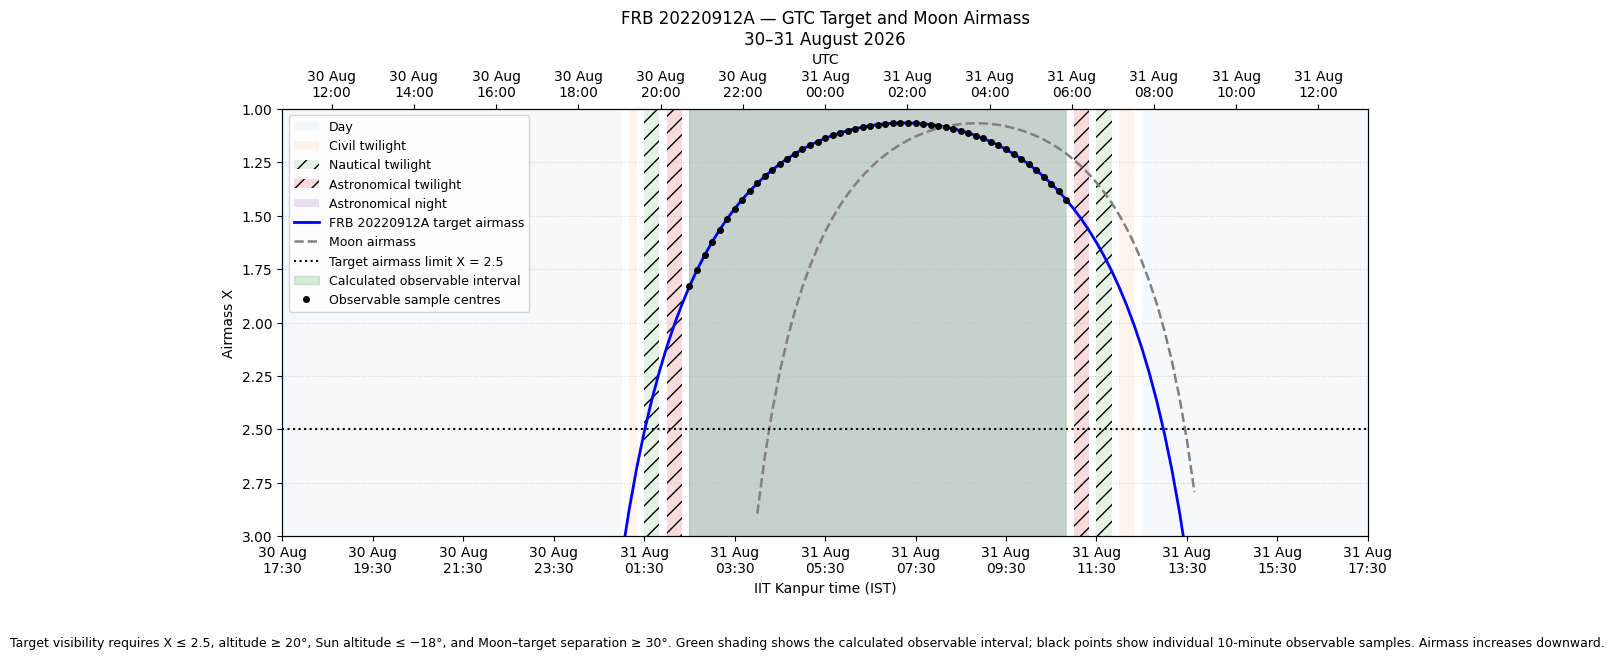

In [58]:
def stitch_windows(times, visibility_state):
    """
    Find consecutive inclusive sample-centre visibility intervals.

    Parameters
    ----------
    times : Astropy Time array
        Time grid corresponding to the visibility samples.
    visibility_state : Boolean array
        True for observable samples and False otherwise.

    Returns
    -------
    windows : list of tuples
        Each tuple contains:
        (start_index, end_index, start_time, end_time)
    """

    times = Time(times)
    visibility_state = np.asarray(visibility_state, dtype=bool)

    # Check that the inputs have the same length.
    if len(times) != len(visibility_state):
        raise ValueError(
            "times and visibility_state must have the same length."
        )

    windows = []

    # Handle the empty-input case.
    if len(visibility_state) == 0:
        return windows

    start_index = None

    for i, visible in enumerate(visibility_state):

        # Start of a new visibility window.
        if visible and start_index is None:
            start_index = i

        # End of the current visibility window.
        elif not visible and start_index is not None:
            end_index = i - 1

            windows.append(
                (
                    start_index,
                    end_index,
                    times[start_index],
                    times[end_index],
                )
            )

            start_index = None

    # Handle a window that continues through the final sample.
    if start_index is not None:
        end_index = len(visibility_state) - 1

        windows.append(
            (
                start_index,
                end_index,
                times[start_index],
                times[end_index],
            )
        )

    return windows
    # Find all consecutive observable intervals.
visibility_windows = stitch_windows(
    times,
    preferred_visibility
)

print("Number of observable windows:", len(visibility_windows))

for window_number, (
    start_index,
    end_index,
    start_time,
    end_time
) in enumerate(visibility_windows, start=1):

    print(f"\nWindow {window_number}")
    print("Start sample:", start_index)
    print("End sample:", end_index)
    print("Start UTC:", format_utc(start_time))
    print("Start IIT Kanpur time:", format_iitk(start_time))
    print("End UTC:", format_utc(end_time))
    print("End IIT Kanpur time:", format_iitk(end_time))

    duration_hours = (
        end_time - start_time
    ).to_value(u.hour)

    print(
        "Sample-centre duration:",
        f"{duration_hours:.4f} hours"
    )
    # Report the physical properties of each observing window.

for window_number, (
    start_index,
    end_index,
    start_time,
    end_time
) in enumerate(visibility_windows, start=1):

    # Indices belonging to this inclusive observing window.
    window_indices = np.arange(start_index, end_index + 1)

    # Best airmass = minimum target airmass within the window.
    best_local_position = np.nanargmin(
        target_airmass[window_indices]
    )
    best_index = window_indices[best_local_position]
    best_airmass = target_airmass[best_index]

    # Midpoint sample of the window.
    midpoint_position = len(window_indices) // 2
    midpoint_index = window_indices[midpoint_position]

    print(f"\n===== Window {window_number} properties =====")

    print(
        "Start:",
        format_utc(start_time),
        "|",
        format_iitk(start_time)
    )

    print(
        "End:",
        format_utc(end_time),
        "|",
        format_iitk(end_time)
    )

    duration_hours = (
        end_time - start_time
    ).to_value(u.hour)

    print(
        "Sample-centre duration:",
        f"{duration_hours:.4f} hours"
    )

    print(
        "Best target airmass:",
        f"{best_airmass:.6f}"
    )

    print(
        "Best-airmass sample index:",
        best_index
    )

    print(
        "Best-airmass UTC:",
        format_utc(times[best_index])
    )

    print(
        "Best-airmass IIT Kanpur time:",
        format_iitk(times[best_index])
    )

    print(
        "Midpoint sample index:",
        midpoint_index
    )

    print(
        "Midpoint UTC:",
        format_utc(times[midpoint_index])
    )

    print(
        "Midpoint IIT Kanpur time:",
        format_iitk(times[midpoint_index])
    )

    print(
        "Midpoint Moon label:",
        moon_label[midpoint_index]
    )
    # : Make the required GTC airmass figure.
#
# The plot shows:
#   1. Target airmass
#   2. Moon airmass
#   3. The airmass limit X = 2.5
#   4. Twilight/night background bands
#   5. The calculated observable interval
#   6. Observable sample centres
#
# The horizontal axis is plotted internally in UTC, while the main
# (bottom) axis is labelled in IIT Kanpur time and the aligned
# top axis is labelled in UTC.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timezone

# ------------------------------------------------------------
# Convert Astropy Time values to Python datetime objects.
# ------------------------------------------------------------

utc_datetimes = [
    t.to_datetime(timezone=timezone.utc)
    for t in times
]

iitk_datetimes = [
    t.to_datetime(timezone=IITK_TIMEZONE)
    for t in times
]

# Matplotlib represents dates internally as numbers.
x_values = mdates.date2num(utc_datetimes)

# ------------------------------------------------------------
# Create the figure and main axis.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

# ------------------------------------------------------------
# Background scheduler-style twilight/night bands.
#
# These use standard solar-altitude boundaries:
#   Sun > 0°          : Day
#   -6° to 0°          : Civil twilight
#   -12° to -6°        : Nautical twilight
#   -18° to -12°       : Astronomical twilight
#   Sun <= -18°        : Astronomical night
# ------------------------------------------------------------

sun_altitude_values = sun_altitude.to_value(u.deg)

band_conditions = [
    (
        sun_altitude_values > 0,
        "Day"
    ),
    (
        (sun_altitude_values <= 0)
        & (sun_altitude_values > -6),
        "Civil twilight"
    ),
    (
        (sun_altitude_values <= -6)
        & (sun_altitude_values > -12),
        "Nautical twilight"
    ),
    (
        (sun_altitude_values <= -12)
        & (sun_altitude_values > -18),
        "Astronomical twilight"
    ),
    (
        sun_altitude_values <= -18,
        "Astronomical night"
    )
]

# Use low-opacity bands so that the airmass curves remain visible.
band_alphas = {
    "Day": 0.04,
    "Civil twilight": 0.08,
    "Nautical twilight": 0.12,
    "Astronomical twilight": 0.16,
    "Astronomical night": 0.20
}

# Different hatch patterns make the observing regimes easier to
# distinguish without relying only on colour.
band_hatches = {
    "Day": "",
    "Civil twilight": "",
    "Nautical twilight": "//",
    "Astronomical twilight": "//",
    "Astronomical night": ""
}

for condition, label in band_conditions:

    ax.fill_between(
        x_values,
        1,
        3,
        where=condition,
        alpha=band_alphas[label],
        hatch=band_hatches[label],
        label=label
    )

# ------------------------------------------------------------
# Plot target and Moon airmass.
# ------------------------------------------------------------

ax.plot(
    x_values,
    target_airmass,
    color="blue",
    linewidth=2,
    linestyle="-",
    label="FRB 20220912A target airmass"
)

ax.plot(
    x_values,
    moon_airmass,
    color="gray",
    linewidth=1.8,
    linestyle="--",
    label="Moon airmass"
)

# ------------------------------------------------------------
# Plot the maximum allowed target airmass.
# ------------------------------------------------------------

ax.axhline(
    MAX_AIRMASS,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Target airmass limit X = 2.5"
)

# ------------------------------------------------------------
# Shade the calculated observable intervals in green.
# ------------------------------------------------------------

for (
    start_index,
    end_index,
    start_time,
    end_time
) in visibility_windows:

    start_x = mdates.date2num(
        start_time.to_datetime(timezone=timezone.utc)
    )

    end_x = mdates.date2num(
        end_time.to_datetime(timezone=timezone.utc)
    )

    ax.axvspan(
        start_x,
        end_x,
        color="green",
        alpha=0.15,
        label="Calculated observable interval"
    )

# ------------------------------------------------------------
# Mark every observable sample with a black marker.
# ------------------------------------------------------------

observable_indices = np.where(preferred_visibility)[0]

ax.plot(
    x_values[observable_indices],
    target_airmass[observable_indices],
    linestyle="None",
    marker="o",
    markersize=4,
    color="black",
    label="Observable sample centres"
)

# ------------------------------------------------------------
# Airmass-axis formatting.
#
# Lower airmass is physically better, so astronomical plots
# conventionally display X = 1 at the top and larger X values
# downward.
# ------------------------------------------------------------

ax.set_ylim(3, 1)

ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur time (IST)")

ax.set_title(
    "FRB 20220912A — GTC Target and Moon Airmass\n"
    "30–31 August 2026"
)

# ------------------------------------------------------------
# Create the main x-axis labels in IIT Kanpur time.
#
# One tick every 2 hours gives enough information while keeping
# the figure readable.
# ------------------------------------------------------------

tick_indices = np.arange(0, len(times), 12)

# Make sure the final sample is included.
if tick_indices[-1] != len(times) - 1:
    tick_indices = np.append(
        tick_indices,
        len(times) - 1
    )

tick_positions = x_values[tick_indices]

iitk_labels = [
    dt.strftime("%d %b\n%H:%M")
    for dt in np.array(iitk_datetimes, dtype=object)[tick_indices]
]

utc_labels = [
    dt.strftime("%d %b\n%H:%M")
    for dt in np.array(utc_datetimes, dtype=object)[tick_indices]
]

ax.set_xticks(tick_positions)
ax.set_xticklabels(iitk_labels)

# ------------------------------------------------------------
# Create an aligned UTC axis above the main axis.
# ------------------------------------------------------------

ax_utc = ax.twiny()

ax_utc.set_xlim(ax.get_xlim())

ax_utc.set_xticks(tick_positions)
ax_utc.set_xticklabels(utc_labels)

ax_utc.set_xlabel("UTC")

# ------------------------------------------------------------
# Grid and limits.
# ------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

ax.set_xlim(
    x_values[0],
    x_values[-1]
)

# ------------------------------------------------------------
# Avoid duplicate legend entries from the background bands.
# ------------------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

unique_handles = []
unique_labels = []

for handle, label in zip(handles, labels):

    if label not in unique_labels:
        unique_handles.append(handle)
        unique_labels.append(label)

ax.legend(
    unique_handles,
    unique_labels,
    loc="upper left",
    fontsize=9
)

# ------------------------------------------------------------
# Add an explanatory caption.
# ------------------------------------------------------------

caption = (
    "Target visibility requires X ≤ 2.5, altitude ≥ 20°, "
    "Sun altitude ≤ −18°, and Moon–target separation ≥ 30°. "
    "Green shading shows the calculated observable interval; "
    "black points show individual 10-minute observable samples. "
    "Airmass increases downward."
)

fig.text(
    0.5,
    0.015,
    caption,
    ha="center",
    va="bottom",
    fontsize=9
)

# Leave space for the caption.
plt.tight_layout(rect=[0, 0.07, 1, 0.95])

# ------------------------------------------------------------

figure_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

print("Figure saved to:")
print(figure_path)

plt.show()

 Explanation: There's one observable window: 21:00 UTC (Aug 30) to 05:20 UTC (Aug 31)—that's 8.33 hours in sample-centre duration. The best airmass (1.064965) occurs at transit (index 82). The midpoint sample (index 79) has a Bright Moon label, meaning moonlight is a factor.

The airmass figure shows the target's airmass curve, the Moon's airmass, the 2.5 limit, night bands, and the observable window in green. The key takeaway: there's a solid observing opportunity, but Moon brightness is a concern.



# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [59]:
# ============================================================
# GTC visibility window of FRB 20220912A
# Date: 2026-09-01
#
# Visibility conditions:
#   1. Astronomical night: Sun altitude <= -18 degrees
#   2. Target is above the horizon: target altitude > 0 degrees
#   3. Target airmass is physically valid and <= 2.5
#
# We use a 10-minute grid over the complete UTC day.
# This is a single-source calculation for FRB 20220912A,
# not an all-sky HEALPix calculation.
# ============================================================

# ------------------------------------------------------------
# 1. Construct the complete UTC-day time grid.
# ------------------------------------------------------------

q19_start = Time(
    "2026-09-01T00:00:00",
    scale="utc"
)

q19_stop = Time(
    "2026-09-02T00:00:00",
    scale="utc"
)

q19_step = 10 * u.min

q19_number_of_steps = int(
    np.round(
        (q19_stop - q19_start).to_value(u.min)
        / q19_step.to_value(u.min)
    )
)

q19_times = (
    q19_start
    + np.arange(q19_number_of_steps + 1) * q19_step
)

print("Number of time samples:", len(q19_times))
print("First sample:", format_utc(q19_times[0]))
print("Last sample:", format_utc(q19_times[-1]))


# ------------------------------------------------------------
# 2. Calculate the target altitude and airmass at GTC.
# ------------------------------------------------------------

q19_altaz_frame = AltAz(
    obstime=q19_times,
    location=gtc_location,
    pressure=0 * u.hPa
)

q19_frb_altaz = frb_icrs.transform_to(
    q19_altaz_frame
)

q19_target_altitude = (
    q19_frb_altaz.alt.to_value(u.deg)
)

q19_target_airmass = np.asarray(
    q19_frb_altaz.secz,
    dtype=float
)

# Airmass is physically usable only when the target is
# above the horizon and the value is finite and >= 1.
q19_target_airmass[
    (q19_target_altitude <= 0)
    | ~np.isfinite(q19_target_airmass)
    | (q19_target_airmass < 1)
] = np.nan


# ------------------------------------------------------------
# 3. Calculate Sun altitude.
# ------------------------------------------------------------

q19_sun = get_sun(q19_times)

q19_sun_altaz = q19_sun.transform_to(
    q19_altaz_frame
)

q19_sun_altitude = (
    q19_sun_altaz.alt.to_value(u.deg)
)


# ------------------------------------------------------------
# 4. Apply the three visibility conditions.
# ------------------------------------------------------------

# Condition 1:
# Astronomical night.
q19_night_ok = (
    q19_sun_altitude <= -18.0
)

# Condition 2:
# Target must be above the horizon.
q19_altitude_ok = (
    q19_target_altitude > 0.0
)

# Condition 3:
# Target airmass must be finite and <= 2.5.
q19_airmass_ok = (
    np.isfinite(q19_target_airmass)
    & (q19_target_airmass >= 1.0)
    & (q19_target_airmass <= 2.5)
)

# All three conditions must be satisfied simultaneously.
q19_visibility = (
    q19_night_ok
    & q19_altitude_ok
    & q19_airmass_ok
)


# ------------------------------------------------------------
# 5. Print diagnostic counts.
# ------------------------------------------------------------

print("\nCondition counts:")
print(
    "Astronomical night:",
    np.count_nonzero(q19_night_ok)
)

print(
    "Target above horizon:",
    np.count_nonzero(q19_altitude_ok)
)

print(
    "Target airmass 1 <= X <= 2.5:",
    np.count_nonzero(q19_airmass_ok)
)

print(
    "All three conditions:",
    np.count_nonzero(q19_visibility)
)


# ------------------------------------------------------------
# 6. Stitch consecutive visible samples into intervals.
#
# We reuse the stitch_windows() function implemented in Q18.
# ------------------------------------------------------------

q19_windows = stitch_windows(
    q19_times,
    q19_visibility
)

print(
    "\nNumber of GTC visibility windows:",
    len(q19_windows)
)


# ------------------------------------------------------------
# 7. Report each contiguous visibility interval.
# ------------------------------------------------------------

total_visible_duration = 0.0

for window_number, (
    start_index,
    end_index,
    start_time,
    end_time
) in enumerate(q19_windows, start=1):

    # Number of visible sample centres.
    number_of_samples = (
        end_index - start_index + 1
    )

    # Duration between the first and last visible
    # sample centres.
    duration_hours = (
        end_time - start_time
    ).to_value(u.hour)

    total_visible_duration += duration_hours

    print(
        f"\n===== Visibility Window {window_number} ====="
    )

    print(
        "Start UTC:",
        format_utc(start_time)
    )

    print(
        "Start IIT Kanpur time:",
        format_iitk(start_time)
    )

    print(
        "End UTC:",
        format_utc(end_time)
    )

    print(
        "End IIT Kanpur time:",
        format_iitk(end_time)
    )

    print(
        "Number of visible samples:",
        number_of_samples
    )

    print(
        "Sample-centre duration:",
        f"{duration_hours:.4f} hours"
    )


# ------------------------------------------------------------
# 8. Print the total visible duration.
# ------------------------------------------------------------

print(
    "\nTotal visible duration "
    "(sample-centre duration):",
    f"{total_visible_duration:.4f} hours"
)

Number of time samples: 145
First sample: 2026-09-01 00:00:00 UTC
Last sample: 2026-09-02 00:00:00 UTC

Condition counts:
Astronomical night: 52
Target above horizon: 104
Target airmass 1 <= X <= 2.5: 70
All three conditions: 52

Number of GTC visibility windows: 2

===== Visibility Window 1 =====
Start UTC: 2026-09-01 00:00:00 UTC
Start IIT Kanpur time: 2026-09-01 05:30:00 IST
End UTC: 2026-09-01 05:20:00 UTC
End IIT Kanpur time: 2026-09-01 10:50:00 IST
Number of visible samples: 33
Sample-centre duration: 5.3333 hours

===== Visibility Window 2 =====
Start UTC: 2026-09-01 21:00:00 UTC
Start IIT Kanpur time: 2026-09-02 02:30:00 IST
End UTC: 2026-09-02 00:00:00 UTC
End IIT Kanpur time: 2026-09-02 05:30:00 IST
Number of visible samples: 19
Sample-centre duration: 3.0000 hours

Total visible duration (sample-centre duration): 8.3333 hours


Explanation: For 2026-09-01, the FRB is visible in two windows:

1. 00:00–05:20 UTC (5.33 hours)

2. 21:00–00:00 UTC (3.00 hours)

Total: 8.33 hours. The 10-minute grid gives 52 samples that meet all three conditions (night, above horizon, X ≤ 2.5). The two windows are separated by the daytime gap.




## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [60]:
# ============================================================
# Q20 — Weekly all-sky GTC visibility animation
# ============================================================
#
# We represent the entire celestial sphere using a HEALPix grid.
# Each HEALPix pixel corresponds to one sky direction.
#
# NSIDE = 32 gives:
#     NPIX = 12 * NSIDE^2 = 12,288 pixels
#
# This is a moderate resolution suitable for an animation.
# ============================================================

import healpy as hp
import imageio.v2 as imageio

Q20_NSIDE = 32

q20_npix = hp.nside2npix(Q20_NSIDE)

print("HEALPix NSIDE:", Q20_NSIDE)
print("Number of sky pixels:", q20_npix)
# ------------------------------------------------------------
# Generate one frame every 7 days.
# ------------------------------------------------------------

Q20_START_DATE = Time(
    "2026-08-30T00:00:00",
    scale="utc"
)

Q20_STOP_DATE = Time(
    "2027-08-29T00:00:00",
    scale="utc"
)

Q20_STEP = 7 * u.day

q20_dates = (
    Q20_START_DATE
    + np.arange(
        int(
            np.floor(
                (
                    Q20_STOP_DATE - Q20_START_DATE
                ).to_value(u.day)
                / 7
            )
        ) + 1
    ) * Q20_STEP
)

print("Number of weekly frames:", len(q20_dates))
print("First frame:", format_utc(q20_dates[0]))
print("Last frame:", format_utc(q20_dates[-1]))
# ------------------------------------------------------------
# Convert HEALPix pixel centres into celestial coordinates.
# ------------------------------------------------------------
#
# HEALPix uses:
#   theta = polar angle measured from the north celestial pole
#   phi   = azimuthal angle around the sphere
#
# We convert these to:
#   RA  = phi
#   Dec = 90° - theta
#
# These coordinates describe the direction of every sky pixel.
# ------------------------------------------------------------

q20_pixel_indices = np.arange(q20_npix)

q20_theta, q20_phi = hp.pix2ang(
    Q20_NSIDE,
    q20_pixel_indices
)

q20_ra = q20_phi * u.rad

q20_dec = (
    (np.pi / 2 - q20_theta) * u.rad
)

print(
    "RA range:",
    f"{q20_ra.to_value(u.deg).min():.2f}° to "
    f"{q20_ra.to_value(u.deg).max():.2f}°"
)

print(
    "Dec range:",
    f"{q20_dec.to_value(u.deg).min():.2f}° to "
    f"{q20_dec.to_value(u.deg).max():.2f}°"
)
# ------------------------------------------------------------
# Calculate the midpoint of astronomical night for one date.
# ------------------------------------------------------------
#
# Astronomical night occurs when:
#
#       Sun altitude <= -18 degrees
#
# We search a 24-hour period around each weekly reference date
# and use the first and last astronomical-night samples to
# define a representative midpoint.
# ------------------------------------------------------------

def astronomical_night_midpoint(reference_time):
    """
    Return the midpoint of the astronomical-night interval
    surrounding the supplied UTC reference time.
    """

    night_times = (
        reference_time
        + np.arange(-72, 73) * 10 * u.min
    )

    frame = AltAz(
        obstime=night_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    sun = get_sun(night_times)

    sun_altaz = sun.transform_to(frame)

    sun_altitude = sun_altaz.alt.to_value(u.deg)

    night = sun_altitude <= -18.0

    if not np.any(night):
        return None

    first_index = np.where(night)[0][0]
    last_index = np.where(night)[0][-1]

    midpoint = (
        night_times[first_index]
        + (
            night_times[last_index]
            - night_times[first_index]
        ) / 2
    )

    return midpoint


# Test the function on the first weekly frame.
q20_test_midpoint = astronomical_night_midpoint(
    q20_dates[0]
)

print(
    "Astronomical-night midpoint:",
    format_utc(q20_test_midpoint)
)

print(
    "IIT Kanpur time:",
    format_iitk(q20_test_midpoint)
)
# ------------------------------------------------------------
# Calculate an all-sky visibility map for one time.
# ------------------------------------------------------------

def calculate_q20_visibility(observing_time):
    """
    Calculate the GTC visibility state for every HEALPix pixel
    at one observing time.

    Returns
    -------
    visible : Boolean array
        True for sky pixels satisfying all visibility conditions.
    altitude : float array
        Altitude of every HEALPix pixel in degrees.
    airmass : float array
        Airmass of every HEALPix pixel.
    """

    # Create ICRS coordinates for every HEALPix pixel.
    sky_coordinates = SkyCoord(
        ra=q20_ra,
        dec=q20_dec,
        frame="icrs"
    )

    # Transform all sky directions to GTC AltAz.
    altaz_frame = AltAz(
        obstime=observing_time,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    sky_altaz = sky_coordinates.transform_to(
        altaz_frame
    )

    altitude = (
        sky_altaz.alt.to_value(u.deg)
    )

    airmass = np.asarray(
        sky_altaz.secz,
        dtype=float
    )

    # --------------------------------------------------------
    # Calculate Sun altitude.
    # --------------------------------------------------------

    sun = get_sun(observing_time)

    sun_altaz = sun.transform_to(
        altaz_frame
    )

    sun_altitude = (
        sun_altaz.alt.to_value(u.deg)
    )

    # --------------------------------------------------------
    # Visibility conditions.
    # --------------------------------------------------------

    altitude_ok = (
        altitude > 0.0
    )

    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1.0)
        & (airmass <= 2.5)
    )

    night_ok = (
        sun_altitude <= -18.0
    )

    visible = (
        altitude_ok
        & airmass_ok
        & night_ok
    )

    return (
        visible,
        altitude,
        airmass
    )


# Test the calculation for the first weekly frame.

q20_visible, q20_altitude, q20_airmass = (
    calculate_q20_visibility(q20_test_midpoint)
)

print(
    "Visible HEALPix pixels:",
    np.count_nonzero(q20_visible)
)

print(
    "Fraction of sky visible:",
    f"{np.mean(q20_visible):.3f}"
)
# ============================================================
# Q20 — Generate weekly all-sky HEALPix visibility animation
# ============================================================

# Directory for individual PNG frames.
Q20_FRAME_DIR = (
    OUTPUT_DIR / "q20_frames"
)

Q20_FRAME_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# List that will contain the paths of all generated frames.
q20_frame_paths = []


# ------------------------------------------------------------
# Generate one frame for every weekly date.
# ------------------------------------------------------------

for frame_number, reference_time in enumerate(
    q20_dates,
    start=1
):

    print(
        f"Generating frame {frame_number}/{len(q20_dates)}..."
    )

    # --------------------------------------------------------
    # Find the midpoint of astronomical night.
    # --------------------------------------------------------

    observing_time = astronomical_night_midpoint(
        reference_time
    )

    if observing_time is None:
        print(
            "  No astronomical night found; skipping frame."
        )
        continue

    # --------------------------------------------------------
    # Calculate visibility of every HEALPix pixel.
    # --------------------------------------------------------

    visible, altitude, airmass = (
        calculate_q20_visibility(
            observing_time
        )
    )

    # --------------------------------------------------------
    # Create a HEALPix map.
    #
    # Visible pixels are assigned the value 1.
    # Non-visible pixels are assigned NaN so they are
    # not displayed as visible.
    # --------------------------------------------------------

    visibility_map = np.full(
        q20_npix,
        np.nan
    )

    visibility_map[visible] = 1.0

    # --------------------------------------------------------
    # Create the all-sky figure.
    # --------------------------------------------------------

    fig = plt.figure(
        figsize=(10, 6)
    )

    hp.mollview(
        visibility_map,
        fig=fig.number,
        title=(
            "GTC All-Sky Visibility of FRB Directions\n"
            f"{format_utc(observing_time)}"
        ),
        unit="Visible",
        xsize=1200,
        notext=False,
        cbar=False
    )

    # Add a colour bar manually.
    hp.graticule(
        dpar=30,
        dmer=30
    )

    # --------------------------------------------------------
    # Add explanatory text.
    # --------------------------------------------------------

    fig.text(
        0.5,
        0.03,
        (
            "Visible = astronomical night, target above horizon, "
            "and target airmass ≤ 2.5\n"
            f"Weekly frame {frame_number}/{len(q20_dates)}"
        ),
        ha="center",
        fontsize=9
    )

    # --------------------------------------------------------
    # Save the PNG frame.
    # --------------------------------------------------------

    frame_path = (
        Q20_FRAME_DIR
        / f"gtc_visibility_{frame_number:03d}.png"
    )

    fig.savefig(
        frame_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    q20_frame_paths.append(
        frame_path
    )


# ------------------------------------------------------------
# Create the GIF from all PNG frames.
# ------------------------------------------------------------

gif_path = (
    OUTPUT_DIR
    / "frb_20220912a_gtc_visibility.gif"
)

with imageio.get_writer(
    gif_path,
    mode="I",
    duration=0.5,
    loop=0
) as writer:

    for frame_path in q20_frame_paths:

        frame = imageio.imread(
            frame_path
        )

        writer.append_data(
            frame
        )


# ------------------------------------------------------------
# Final report.
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Q20 COMPLETE")
print("=" * 60)

print(
    "Number of PNG frames:",
    len(q20_frame_paths)
)

print(
    "Frame directory:",
    Q20_FRAME_DIR
)

print(
    "GIF saved to:",
    gif_path
)

HEALPix NSIDE: 32
Number of sky pixels: 12288
Number of weekly frames: 53
First frame: 2026-08-30 00:00:00 UTC
Last frame: 2027-08-29 00:00:00 UTC
RA range: 0.00° to 358.59°
Dec range: -88.54° to 88.54°
Astronomical-night midpoint: 2026-08-30 01:10:00 UTC
IIT Kanpur time: 2026-08-30 06:40:00 IST
Visible HEALPix pixels: 3695
Fraction of sky visible: 0.301
Generating frame 1/53...


/usr/local/lib/python3.13/dist-packages/healpy/visufunc.py:225: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Generating frame 2/53...
Generating frame 3/53...
Generating frame 4/53...
Generating frame 5/53...
Generating frame 6/53...
Generating frame 7/53...
Generating frame 8/53...
Generating frame 9/53...
Generating frame 10/53...
Generating frame 11/53...
Generating frame 12/53...
Generating frame 13/53...
Generating frame 14/53...
Generating frame 15/53...
Generating frame 16/53...
Generating frame 17/53...
Generating frame 18/53...
Generating frame 19/53...
Generating frame 20/53...
Generating frame 21/53...
Generating frame 22/53...
Generating frame 23/53...
Generating frame 24/53...
Generating frame 25/53...
Generating frame 26/53...
Generating frame 27/53...
Generating frame 28/53...
Generating frame 29/53...
Generating frame 30/53...
Generating frame 31/53...
Generating frame 32/53...
Generating frame 33/53...
Generating frame 34/53...
Generating frame 35/53...
Generating frame 36/53...
Generating frame 37/53...
Generating frame 38/53...
Generating frame 39/53...
Generating frame 40/

Generating frame 52/53...
Generating frame 53/53...

Q20 COMPLETE
Number of PNG frames: 53
Frame directory: assignment_outputs/q20_frames
GIF saved to: assignment_outputs/frb_20220912a_gtc_visibility.gif


### Explanation

For the bonus all-sky calculation, I represented the celestial sphere using a HEALPix grid with \(N_{\rm side}=32\), giving 12,288 sky pixels. Each HEALPix pixel represents a different direction on the celestial sphere.

The calculation was performed once every 7 days from 2026-08-30 to 2027-08-29, giving 53 weekly frames. For each date, I selected a representative time near the midpoint of astronomical night, defined by the Sun being at or below \(-18^\circ\).

For every HEALPix sky direction, I transformed its ICRS coordinates to the GTC AltAz frame and calculated its altitude and airmass. A direction was marked as visible when it satisfied all three conditions:

1. The Sun altitude was at or below \(-18^\circ\), corresponding to astronomical night.
2. The sky direction was above the horizon.
3. The airmass was finite and within \(1\leq X\leq2.5\).

For the first frame, on 2026-08-30, 3,695 of the 12,288 HEALPix pixels were visible, corresponding to approximately 30.1% of the sky.

The resulting 53 PNG frames were combined into a GIF animation. The animation shows how the region of sky satisfying the GTC visibility conditions changes over the year as the apparent position of the Sun changes relative to the celestial coordinate system.

This is an all-sky calculation, unlike Q19, which considered only the single source FRB 20220912A. The HEALPix resolution is moderate, so the animation is intended to demonstrate the changing visibility pattern rather than provide a high-precision observing scheduler. The calculation also uses the available Astropy Earth-orientation information; for dates beyond the available IERS data, Astropy used mean polar-motion values, which can introduce small positional errors.


In [61]:
from pathlib import Path

gif_path = Path(
    "assignment_outputs/frb_20220912a_gtc_visibility.gif"
)

print("Exists:", gif_path.exists())
print("Path:", gif_path.resolve())
print("Size:", gif_path.stat().st_size, "bytes")

Exists: True
Path: /content/assignment_outputs/frb_20220912a_gtc_visibility.gif
Size: 733062 bytes


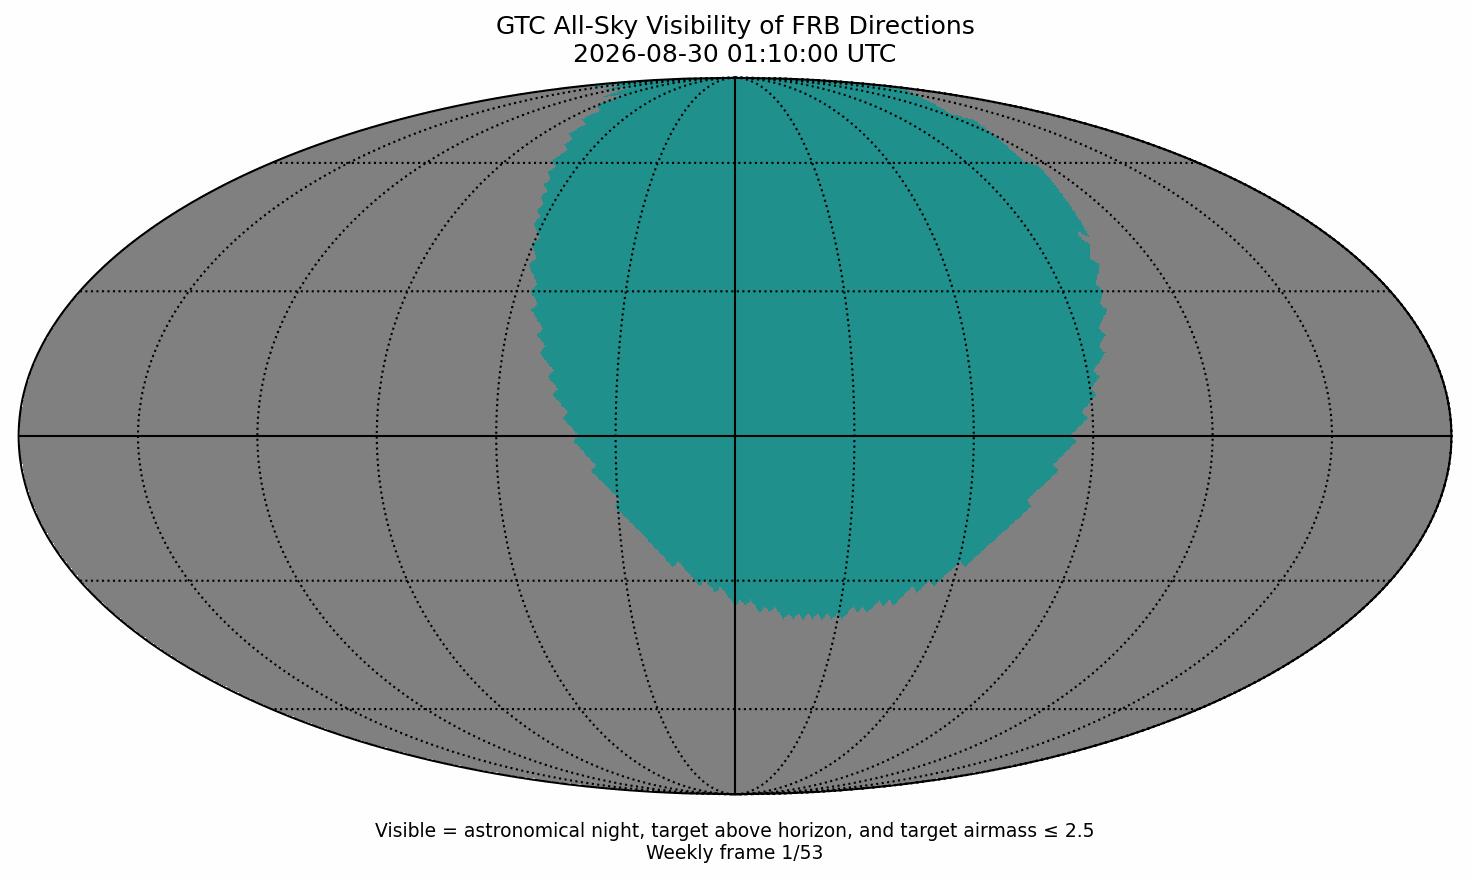

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename="assignment_outputs/frb_20220912a_gtc_visibility.gif"
    )
)

**NOTE ON AI HELP:**
I am a beginner in Python and this is my first experience with coding. This assignment provided me with valuable hands-on training in Python. However, since most of the questions were relatively advanced for my current level, I took the help of AI to understand certain concepts and approaches and took help to write some code blocks. I have made an effort to understand the code and the concepts involved rather than simply using the generated solutions.


## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
